In [ ]:
!pip install pytrends

from pytrends.request import TrendReq

pytrends = TrendReq(hl='en-US', tz=360)



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq


Setup pytrend library and keyword define

In [ ]:
pytrends=TrendReq(hl='en-US',tz=360)
keyword="Cloud computing"

Data Request

In [ ]:
pytrends.build_payload([keyword],cat=0 ,timeframe='today 12-m',geo='',gprop='')

Coutry wise interest

In [ ]:
region_data=pytrends.interest_by_region()
region_data=region_data.sort_values(by=keyword,ascending=False).head(10)

/tmp/ipykernel_1802/1387296758.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




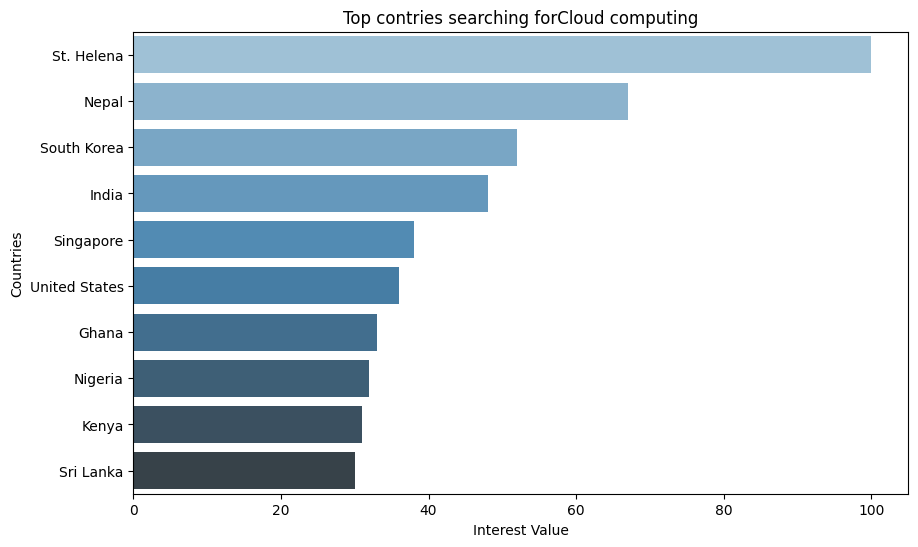

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=region_data[keyword],y=region_data.index,palette='Blues_d')
plt.title(f"Top contries searching for{keyword}")
plt.xlabel("Interest Value")
plt.ylabel("Countries")
plt.show()


World map

In [ ]:
fig=px.choropleth(region_data,
                  locations='geoName',
                  locationmode='country names',
                  color=keyword,
                  title=f"{keyword} Interest by Country",
                  color_continuous_scale='Blues'
                  )
fig.show()

Time wise interest

In [ ]:
time_df=pytrends.interest_over_time()


/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



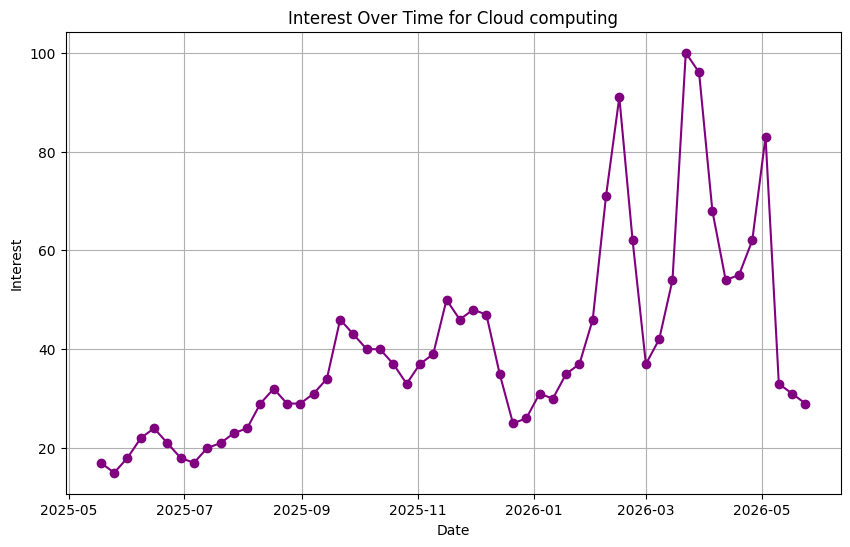

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(time_df.index,time_df[keyword],marker='o',color='purple')
plt.title(f"Interest Over Time for {keyword}")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

Multiple keywords compare

In [ ]:
kw_list=['cloud computing','data science','machine learning']
pytrends.build_payload(kw_list,cat=0,timeframe='today 12-m',geo='',gprop='')

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



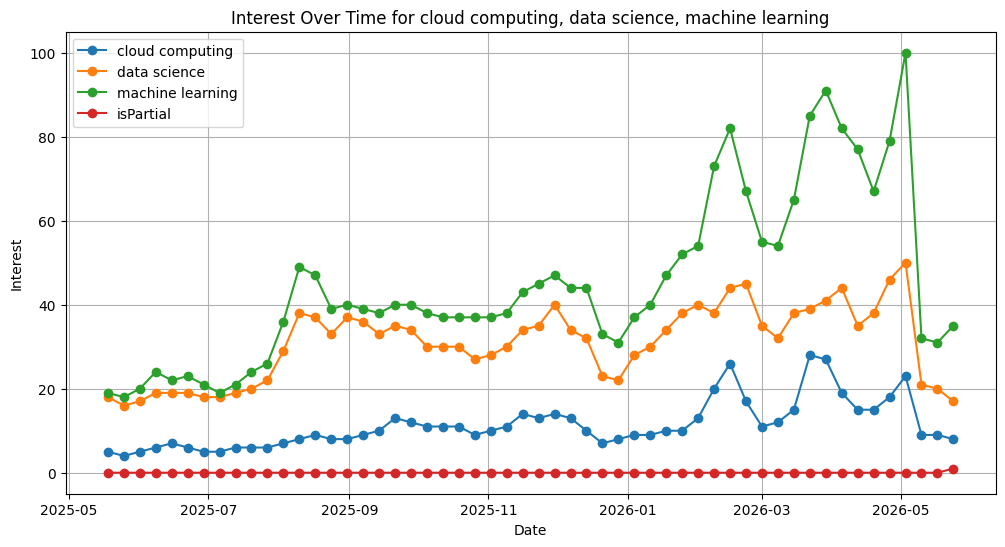

In [ ]:
kw_list=['cloud computing','data science','machine learning']
pytrends.build_payload(kw_list,cat=0,timeframe='today 12-m',geo='',gprop='')

compare_df=pytrends.interest_over_time()

plt.figure(figsize=(12,6))
for col in compare_df.columns:
  plt.plot(compare_df.index,compare_df[col],marker='o',label=col)
plt.legend()
plt.title(f"Interest Over Time for {', '.join(kw_list)}")
plt.xlabel("Date")
plt.ylabel("Interest")
plt.grid(True)
plt.show()